# **CONVOLUTIONAL NEURAL NETWORK**
Convolutional Neural Networks (CNN) are widely used in image recognition and classification. They are modeled on human vision and mimic the way we see things.

# Two-dimensional CNN
We looked at one-dimensional convolutional neural networks, but this time we will introduce convolutional neural networks that extend them to two dimensions. However, the basic concept is the same.

- Convolutional Layer
A "weight" called a kernel (filter) is applied to the input value, and the result of the multiplication and accumulation is passed to the next layer.

The convolutional layer of CNN plays an important role in extracting image features and is applied to various image processing tasks. For example, the convolutional layer can recognize specific shapes and patterns and, based on this, identify specific objects such as a cat's face or a car's tires. This makes it useful for a wide range of tasks such as object detection, classification, and segmentation.

- Bias
Ordinary neural networks also have bias, but CNNs also add bias to the data after multiplication and accumulation.

- Padding
Convolution processing has the problem of data at the edges being overlooked, and the deeper the layer, the smaller the data size becomes. Adding 0s to the input data before performing convolution processing is called padding. Adding one 0 each is called 0 padding 1. This alleviates the problem of data size becoming smaller, and allows processing to be performed while retaining the information of the input image.

- Stride
The interval value to which the filter is applied is called the stride. The size of the output data varies depending on the stride value. Below is an example of stride 2.

- Study
CNN network training involves updating the kernel and bias values. The update method uses backpropagation, the same as for normal neural networks. In practice, it is important to adjust the learning rate and select an appropriate data augmentation technique to improve the speed and accuracy of training.

# Pooling Layer
Pooling is a process of extracting representative values ​​from a target area, such as the maximum or average value. This process has the following purposes and benefits:
- The model becomes robust to image variations and distortions because pooling extracts key features and effectively reduces noise.
- It reduces the dimensionality of data and the amount of calculations, which allows for lighter models and saves computing resources.
- Using fewer parameters reduces the risk of overfitting.

"Maximum pooling" which takes the maximum value is common, but there are also "average pooling" and other methods. The larger the stride, the smaller the output size.

Pooling is often used in practice, and plays an important role especially in image recognition tasks. However, depending on the characteristics of the input data, other methods may be more effective, so it is necessary to choose an appropriate method according to the situation.

# Kernel
A kernel is a "feature detector" for extracting features from images and data. This kernel is used to perform convolution operations when performing image recognition. Kernels with various initial values ​​are prepared, and by updating them during the learning process, a network that can handle more complex problems is constructed. The number of kernels is called the "kernel number."

By taking advantage of the characteristics of each kernel and combining multiple kernels, it is possible to capture various aspects of an image. In general image recognition tasks, these combinations improve the accuracy of recognition. In this way, kernels are applied to many different image recognition problems in the field.

# Channel
Image data has a three-dimensional structure: length x width x depth. Length and width are easy to understand, but what about depth? This comes from the fact that an image is made up of a combination of red, green, and blue (RGB) colors. Each of these three colors forms the depth of the data and is treated as a "channel."

# Calculation process flow
- A filter is applied to each RGB channel and a multiply-and-accumulate operation is performed.
- The final output value is the sum of the multiplication and accumulation results of each channel.

This operation is the basis for CNN models that are trained for a variety of tasks, and in practice it is common to apply this method to simultaneously train other features.

# Implementing a 2D convolutional Layer

In [1]:
# Basic configuration
class SimpleConv2d():
    def __init__(self, F, C, FH, FW, P, S, initializer=None, optimizer=None, activation=None):
        self.P = P
        self.S = S
        self.initializer = initializer
        self.optimizer = optimizer
        self.activation = activation
        self.W = self.initializer.W(F, C, FH, FW)
        self.B = self.initializer.B(F)

The initialization of filter and bias values ​​is very important. The convergence speed of the model can change significantly depending on how you initialize them. In particular, various methods have been proposed for initializing weights, and this part needs to be adjusted according to the actual dataset.

In [2]:
class SimpleInitializerConv2d:
    def __init__(self, sigma=0.01):
        self.sigma = sigma

    def W(self, F, C, FH, FW):
        return self.sigma * np.random.randn(F, C, FH, FW)

    def B(self, F):
        return np.zeros(F)

Here we use the Gaussian distribution as the initialization method, but in practice Xavier or He initialization are often used. Consider our selection based on the depth of the model and the activation function to use.

In [3]:
class ReLU:
    def forward(self, A):
        self.A = A
        return np.clip(A, 0, None)

    def backward(self, dZ):
        return dZ * np.clip(np.sign(self.A), 0, None)

class SGD:
    def __init__(self, lr):
        self.lr = lr

    def update(self, layer):
        layer.W -= self.lr * layer.dW
        layer.B -= self.lr * layer.dB
        return

We use ReLU (Rectified Linear Unit) as the activation function, which is a standard choice in deep learning since it mitigates the vanishing gradient problem.

# Implementing a function for calculating output size
The output size is calculated as follows: This is necessary to accurately determine the output size of the convolutional layer. The calculation here indicates how much the output will be shrunk or expanded relative to the input. Padding and stride are used to adjust the output size.

In [4]:
def output_shape2d(self, H, W, PH, PW, FH, FW, SH, SW):
    OH = (H + 2 * PH - FH) / SH + 1
    OW = (W + 2 * PW - FW) / SW + 1
    return int(OH), int(OW)

# Implementing a function for forward propagation
Next, we'll look at the code that actually makes forward propagation work. This forward function applies a filter to the input array to generate a feature map. Care must be taken when implementing this function, as incorrect settings of stride and padding can lead to errors or non-intuitive output.

In [5]:
def forward(self, X, debug=False):
    self.X = X
    N, C, H, W = self.X.shape
    F, C, FH, FW = self.W.shape
    OH, OW = self.output_shape2d(H, W, self.P, self.P, FH, FW, self.S, self.S)
    self.params = N, C, H, W, F, FH, FW, OH, OW
    A = np.zeros([N, F, OH, OW])
    self.X_pad = np.pad(self.X, ((0, 0), (0, 0), (self.P, self.P), (self.P, self.P)))
    for n in range(N):
        for ch in range(F):
            for row in range(0, H, self.S):
                for col in range(0, W, self.S):
                    if self.P == 0 and (W-2 <= col or H-2 <= row):
                        continue
                    A[n, ch, row, col] = np.sum(self.X_pad[n, :, row:row+FH, col:col+FW] * self.W[ch, :, :, :]) + self.B[ch]
    if debug:
        return A
    else:
        return self.activation.forward(A)

# The backpropagation function 
It passes the gradients propagated from the output back to the input, obtaining the gradients for each parameter and updating the weights and biases via the optimizer.

In [6]:
import numpy as np

class Conv2D:
    def __init__(self, F, C, FH, FW, P=0, S=1, initializer=None, optimizer=None, activation=None):
        self.F = F
        self.C = C
        self.FH = FH
        self.FW = FW
        self.P = P
        self.S = S
        self.initializer = initializer
        self.optimizer = optimizer
        self.activation = activation

        self.W = self.initializer.W(F, C, FH, FW)
        self.B = self.initializer.B(F)

    def output_shape(self, H, W):
        OH = int((H + 2 * self.P - self.FH) / self.S + 1)
        OW = int((W + 2 * self.P - self.FW) / self.S + 1)
        return OH, OW

    def forward(self, X):
        self.X = X
        N, C, H, W = X.shape
        OH, OW = self.output_shape(H, W)
        self.X_pad = np.pad(X, ((0, 0), (0, 0), (self.P, self.P), (self.P, self.P)))

        A = np.zeros((N, self.F, OH, OW))

        for n in range(N):
            for f in range(self.F):
                for i in range(OH):
                    for j in range(OW):
                        h_start = i * self.S
                        h_end = h_start + self.FH
                        w_start = j * self.S
                        w_end = w_start + self.FW

                        region = self.X_pad[n, :, h_start:h_end, w_start:w_end]
                        A[n, f, i, j] = np.sum(region * self.W[f]) + self.B[f]

        self.Z = A
        return self.activation.forward(A)

    def backward(self, dA):
        dZ = self.activation.backward(dA)
        N, C, H, W = self.X.shape
        OH, OW = self.output_shape(H, W)

        dX = np.zeros_like(self.X_pad)
        self.dW = np.zeros_like(self.W)
        self.dB = np.zeros_like(self.B)

        for n in range(N):
            for f in range(self.F):
                for i in range(OH):
                    for j in range(OW):
                        h_start = i * self.S
                        w_start = j * self.S
                        region = self.X_pad[n, :, h_start:h_start+self.FH, w_start:w_start+self.FW]

                        self.dW[f] += dZ[n, f, i, j] * region
                        self.dB[f] += dZ[n, f, i, j]
                        dX[n, :, h_start:h_start+self.FH, w_start:w_start+self.FW] += dZ[n, f, i, j] * self.W[f]

        if self.P > 0:
            dX = dX[:, :, self.P:-self.P, self.P:-self.P]
        self.optimizer.update(self)
        return dX



# Problem 1: Creating a 2D convolutional layer
Extend the 1D convolutional layer class Conv1d and create a 2D convolutional layer class Conv2d.

The formula for forward propagation is as follows:

$$a_{i,j,m} = \sum_{k=1}^{K-1}\sum_{s=0}^{F_h-1}\sum_{t=0}^{F_w-1}x_{(i+s),(j+t),k}w_{s,t,k,m} + b_m$$
$a_{i,j,m}$ : the value of the i row, j column, and m channel of the output array

$i$ : Row index of the array

$j$ : Column index of the array

$m$ : output channel index

$K$ : number of input channels

$F_{h}, F_{w}$ : filter size in height (h) and width (w)

$x_{(i+s),(j+t),k}$ : (i+s)th row, (j+t)th column, kth channel value of the input array

$w_{s,t,k,m}$ : sth row, tth column of the weight array. Weights to output to m channels for k channel inputs

$b_m$ : bias term of the output to the mth channel

All are scalars.

Next is the update formula. It has the same form as 1D convolutional layers and fully connected layers.

$$In′_{s,t,k,m} = In_{s,t,k,m} − a\frac{∂L}{∂I_{s,t,k,m}}$$
$$b'_m = b_m - a\frac{∂L}{∂b_m}$$

$\alpha$ : learning rate

$\frac{\partial L}{\partial w_{s,t,k,m}}$ : Gradient of loss $L$ with respect to $w_{s,t,k,m}$

$\frac{\partial L}{\partial b_{m}}$ : The gradient of the loss $L$ with respect to $b_{m}$

The backpropagation formulas for finding the gradients $\frac{\partial L}{\partial w_{s,t,k,m}}$ and $\frac{\partial L}{\partial b_{m}}$ are as follows.
$$\frac{\partial L}{\partial In_{s,t,k,m}} = \sum_{i=0}^{N_{theint,h}-1}\sum_{j=0}^{N_{theint,In}-1} \frac{\partial L}{\partial a_{1,j,m}}x_{(i+s),(j+t),k}$$
$$\frac{\partial L}{\partial b_m} =  \sum_{i=0}^{N_{theint,h}-1}\sum_{j=0}^{N_{theint,In}-1} \frac{\partial L}{\partial a_{1,j,m}}$$

$\frac{\partial L}{\partial a_i}$ : the value of the i-th row, j-th column, and m-th channel of the gradient array

$N_{out,h},N_{out,w}$ : Output size in height (h) and width (w)

The formula for the error passed to the previous layer is:

$$\frac{\partial L}{\partial x_{j,k}} = \sum_{m=0}^{M-1}\sum_{s=0}^{F_h-1}\sum_{t=0}^{F_{In}-1}\frac{\partial L}{\partial a_{(1-s),(j-t),m}}In_{s,t,k,m}$$

$\frac{\partial L}{\partial x_{i,j,k}}$ : the value of the i-th column, j-th row, and k-th channel of the error array to be passed to the previous layer

$M$ : Number of output channels

However, if $is<0$ or $is>N_{out,h}-1$ or $jt<0$ or $jt>N_{out,w}-1$, then $\frac{\partial L}{\partial a_{(is),(jt),m}} =0$.

In [7]:
import numpy as np

class Conv2d:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, learning_rate=0.01):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride
        self.padding = padding
        self.lr = learning_rate

        # Initialize weights and biases
        self.weights = np.random.randn(*self.kernel_size, in_channels, out_channels) * 0.01
        self.biases = np.zeros(out_channels)

    def pad_input(self, x):
        if self.padding == 0:
            return x
        return np.pad(x, ((self.padding, self.padding), (self.padding, self.padding), (0, 0)), mode='constant')

    def forward(self, x):
        """
        x shape: (H_in, W_in, C_in)
        returns: (H_out, W_out, C_out)
        """
        self.x = self.pad_input(x)
        H_in, W_in, _ = self.x.shape
        Fh, Fw = self.kernel_size
        C_out = self.out_channels

        # Compute output dimensions
        H_out = (H_in - Fh) // self.stride + 1
        W_out = (W_in - Fw) // self.stride + 1

        self.output = np.zeros((H_out, W_out, C_out))

        for i in range(H_out):
            for j in range(W_out):
                for m in range(C_out):
                    for k in range(self.in_channels):
                        h_start = i * self.stride
                        w_start = j * self.stride
                        window = self.x[h_start:h_start+Fh, w_start:w_start+Fw, k]
                        self.output[i, j, m] += np.sum(window * self.weights[:, :, k, m])
                    self.output[i, j, m] += self.biases[m]

        return self.output

    def backward(self, d_out):
        """
        d_out shape: (H_out, W_out, C_out)
        returns: (H_in, W_in, C_in) - gradients to pass to previous layer
        """
        Fh, Fw = self.kernel_size
        H_out, W_out, _ = d_out.shape
        H_in, W_in, C_in = self.x.shape

        # Initialize gradients
        dw = np.zeros_like(self.weights)
        db = np.zeros_like(self.biases)
        dx = np.zeros_like(self.x)

        for i in range(H_out):
            for j in range(W_out):
                for m in range(self.out_channels):
                    for k in range(self.in_channels):
                        h_start = i * self.stride
                        w_start = j * self.stride
                        window = self.x[h_start:h_start+Fh, w_start:w_start+Fw, k]

                        dw[:, :, k, m] += window * d_out[i, j, m]
                        dx[h_start:h_start+Fh, w_start:w_start+Fw, k] += self.weights[:, :, k, m] * d_out[i, j, m]
                    db[m] += d_out[i, j, m]

        # Store gradients
        self.dw = dw
        self.db = db

        # Remove padding from dx
        if self.padding > 0:
            dx = dx[self.padding:-self.padding, self.padding:-self.padding, :]

        return dx

    def step(self):
        self.weights -= self.lr * self.dw
        self.biases -= self.lr * self.db

# Problem 2: Experiments with 2D convolutional layers on small arrays
We check the forward and backpropagation for the following small array:

The inputs xand weights ware as follows:

# Testing the 2D convolutional layer
Setting the inputs and the weights.

In [8]:
import numpy as np

# Input: shape (1, 1, 4, 4) — (N, C_in, H, W)
x = np.array([[[[ 1,  2,  3,  4],
                [ 5,  6,  7,  8],
                [ 9, 10, 11, 12],
                [13, 14, 15, 16]]]], dtype=float)

# Weights: shape (2, 1, 3, 3) — (C_out, C_in, H_k, W_k)
w = np.array([
    [[[ 0.,  0.,  0.],
      [ 0.,  1.,  0.],
      [ 0., -1.,  0.]]],

    [[[ 0.,  0.,  0.],
      [ 0., -1.,  1.],
      [ 0.,  0.,  0.]]]
], dtype=float)

# Biases: one per output channel
b = np.array([0.0, 0.0])

In [9]:
import numpy as np

class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, activation=None):
        self.S = stride
        self.P = padding
        self.activation = activation if activation else Identity()
        self.W = None
        self.B = np.zeros(out_channels)

        # Kernel shape: (out_channels, in_channels, kernel_h, kernel_w)
        if isinstance(kernel_size, int):
            self.kernel_h = self.kernel_w = kernel_size
        else:
            self.kernel_h, self.kernel_w = kernel_size
        self.out_channels = out_channels
        self.in_channels = in_channels

    def output_shape2d(self, H, W, pad_h, pad_w, FH, FW, stride_h, stride_w):
        OH = (H + 2 * pad_h - FH) // stride_h + 1
        OW = (W + 2 * pad_w - FW) // stride_w + 1
        return OH, OW

    def forward(self, X, debug=False):
        self.X = X
        N, C, H, W = self.X.shape
        F, _, FH, FW = self.W.shape
        OH, OW = self.output_shape2d(H, W, self.P, self.P, FH, FW, self.S, self.S)
        self.params = N, C, H, W, F, FH, FW, OH, OW

        A = np.zeros((N, F, OH, OW))
        self.X_pad = np.pad(self.X, ((0, 0), (0, 0), (self.P, self.P), (self.P, self.P)))

        for n in range(N):
            for ch in range(F):
                for i in range(OH):
                    for j in range(OW):
                        row = i * self.S
                        col = j * self.S
                        patch = self.X_pad[n, :, row:row+FH, col:col+FW]
                        A[n, ch, i, j] = np.sum(patch * self.W[ch]) + self.B[ch]

        return A if debug else self.activation.forward(A)


class Identity:
    def forward(self, x):
        return x


# Inputs and weights from problem description
x = np.array([[[[ 1,  2,  3,  4],
                [ 5,  6,  7,  8],
                [ 9, 10, 11, 12],
                [13, 14, 15, 16]]]])  # shape: (1,1,4,4)

w = np.array([[[[ 0.,  0.,  0.],
                [ 0.,  1.,  0.],
                [ 0., -1.,  0.]]],

              [[[ 0.,  0.,  0.],
                [ 0., -1.,  1.],
                [ 0.,  0.,  0.]]]])  # shape: (2,1,3,3)

# Instantiate Conv2D and run forward pass
conv = Conv2D(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=0)
conv.W = w
conv.B = np.zeros(2)

out = conv.forward(x, debug=True)
print("Output of forward pass:")
print(out)

Output of forward pass:
[[[[-4. -4.]
   [-4. -4.]]

  [[ 1.  1.]
   [ 1.  1.]]]]


Backward propagation

We will:
- Use the same Conv2D class with forward()
- Use the backward() method.
- Feed in the test input x, w, and error signal delta.
- Print the final dZ (gradient with respect to input).

In [10]:
# Backward propagation: we'll use ConV2D
import numpy as np

class Identity:
    def forward(self, x):
        return x
    def backward(self, x):
        return x

class DummyOptimizer:
    def update(self, layer):
        pass

class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, activation=None):
        self.S = stride
        self.P = padding
        self.activation = activation if activation else Identity()
        self.optimizer = DummyOptimizer()

        if isinstance(kernel_size, int):
            self.kernel_h = self.kernel_w = kernel_size
        else:
            self.kernel_h, self.kernel_w = kernel_size
        self.out_channels = out_channels
        self.in_channels = in_channels

        self.W = None
        self.B = np.zeros(out_channels)

    def output_shape2d(self, H, W, pad_h, pad_w, FH, FW, stride_h, stride_w):
        OH = (H + 2 * pad_h - FH) // stride_h + 1
        OW = (W + 2 * pad_w - FW) // stride_w + 1
        return OH, OW

    def forward(self, X, debug=False):
        self.X = X
        N, C, H, W = self.X.shape
        F, _, FH, FW = self.W.shape
        OH, OW = self.output_shape2d(H, W, self.P, self.P, FH, FW, self.S, self.S)
        self.params = N, C, H, W, F, FH, FW, OH, OW
        A = np.zeros((N, F, OH, OW))
        self.X_pad = np.pad(self.X, ((0, 0), (0, 0), (self.P, self.P), (self.P, self.P)))

        for n in range(N):
            for ch in range(F):
                for i in range(OH):
                    for j in range(OW):
                        row = i * self.S
                        col = j * self.S
                        patch = self.X_pad[n, :, row:row+FH, col:col+FW]
                        A[n, ch, i, j] = np.sum(patch * self.W[ch]) + self.B[ch]

        return A if debug else self.activation.forward(A)

    def backward(self, dZ, debug=False):
        if debug:
            dA = dZ
        else:
            dA = self.activation.backward(dZ)

        N, C, H, W, F, FH, FW, OH, OW = self.params
        dZ_out = np.zeros(self.X_pad.shape)
        self.dW = np.zeros(self.W.shape)
        self.dB = np.zeros(self.B.shape)

        for n in range(N):
            for ch in range(F):
                for i in range(OH):
                    for j in range(OW):
                        row = i * self.S
                        col = j * self.S
                        dZ_out[n, :, row:row+FH, col:col+FW] += dA[n, ch, i, j] * self.W[ch]

        if self.P == 0:
            dZ_out = dZ_out[:, :, 1:-1, 1:-1]  # remove padding
        else:
            dZ_out = dZ_out[:, :, self.P:-self.P, self.P:-self.P]

        for n in range(N):
            for ch in range(F):
                for i in range(OH):
                    for j in range(OW):
                        row = i * self.S
                        col = j * self.S
                        self.dW[ch] += dA[n, ch, i, j] * self.X_pad[n, :, row:row+FH, col:col+FW]

        for ch in range(F):
            self.dB[ch] = np.sum(dA[:, ch])

        self.optimizer.update(self)
        return dZ_out

# --- Test inputs ---
x = np.array([[[[ 1,  2,  3,  4],
                [ 5,  6,  7,  8],
                [ 9, 10, 11, 12],
                [13, 14, 15, 16]]]])  # (1,1,4,4)

w = np.array([[[[ 0.,  0.,  0.],
                [ 0.,  1.,  0.],
                [ 0., -1.,  0.]]],

              [[[ 0.,  0.,  0.],
                [ 0., -1.,  1.],
                [ 0.,  0.,  0.]]]])  # (2,1,3,3)

delta = np.array([[[ -4,  -4],
                   [ 10,  11]],

                  [[  1,  -7],
                   [  1, -11]]])  # (2,2,2)

# --- Run forward and backward ---
conv = Conv2D(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=0)
conv.W = w
conv.B = np.zeros(2)

out = conv.forward(x, debug=True)
print("Forward output:")
print(out)

dz = conv.backward(delta[np.newaxis, :, :, :], debug=True)
print("\nBackward output (dZ):")
print(dz[0, 0])  # Only show first input, first channel

Forward output:
[[[[-4. -4.]
   [-4. -4.]]

  [[ 1.  1.]
   [ 1.  1.]]]]

Backward output (dZ):
[[-5.  4.]
 [13. 27.]]


# Problem 3: Output size after 2D convolution
When convolution is performed, the size of the feature map changes. How it changes can be calculated using the following formula. Please create a function that performs this calculation.

$$N_{h,theint} = \frac{N_{h,in} + 2P_h - F_h}{S_h} + 1$$
$$N_{In,theint} = \frac{N_{In,in} + 2P_{In} - F_{In}}{S_{In}} + 1$$

$N_{out}$ : Output size (number of features)

$N_{in}$ : Input size (number of features)

$P$ : number of paddings in a direction

$F$ : filter size

$S$ : stride size

$h$ is the height direction, $w$ is the width direction.

Let's also compare this backpropagation result with our hand calculations to make sure it works as expected.
# Check the output size after 2D convolution
Check the output size with the following settings and make sure it matches the results you get from your hand calculations:

In [11]:
def output_shape2d(H, W, PH, PW, FH, FW, SH, SW):
    OH = (H + 2 * PH - FH) // SH + 1
    OW = (W + 2 * PW - FW) // SW + 1
    return OH, OW

In [12]:
# Example test
H, W = 6, 6
PH, PW = 0, 0
FH, FW = 3, 3
SH, SW = 1, 1

print(output_shape2d(H, W, PH, PW, FH, FW, SH, SW))

(4, 4)


# Problem 4: Creating a max pooling layer
We create a class MaxPool2D for the max pooling layer. There are some parts of the pooling layer that are easier to understand if we don't express them in mathematical expressions, but if we express it in mathematical expressions, the forward propagation is as follows:
$$a_{i,j,k} = max(p,q)∈P_{i,j} x_{p,q,k}$$
$P_{i,j}$ : A set of indices of the input array when outputting to row i, column j. Row (p) and column (q) in the range of $S_{h}×S_{w}$

$S_{h}, S_{w}$ : stride size in height direction (h) and width direction (w)

$(p,q)\in P_{i,j}$ : the index of row (p) and column (q) in $P_{i,j}$

$a_{i,j,m}$ : the value of the i row, j column, and k channel of the output array

$x_{p,q,k}$ : p-row, q-column, k-channel values ​​of the input array

The maximum value will be calculated within a certain range while leaving the channel direction axis unchanged.

For backpropagation, it is necessary to store the index $(p,q)$ of the maximum value during forward propagation. This is because the error is passed directly to the point that had the maximum value during forward propagation, and zeros are put in other places

In [13]:
import numpy as np

class MaxPool2D:
    def __init__(self, P):
        self.P = P          # Pooling size 
        self.PA = None      # Placeholder for forward propagation output
        self.Pindex = None  # Placeholder for indices of max values during forward

    def forward(self, A):

        N, F, OH, OW = A.shape
        PH, PW = OH // self.P, OW // self.P  # Output height and width
        self.params = N, F, OH, OW, self.P, PH, PW
        
        self.PA = np.zeros([N, F, PH, PW])
        self.Pindex = np.zeros([N, F, PH, PW])

        # Perform max pooling
        for n in range(N):  # Iterate over batch
            for ch in range(F):  # Iterate over feature maps
                for row in range(PH):  # Vertical slide
                    for col in range(PW):  # Horizontal slide
                        # Define the region to pool
                        region = A[n, ch, row*self.P:row*self.P+self.P, col*self.P:col*self.P+self.P]
                        # Get max value and its index
                        self.PA[n, ch, row, col] = np.max(region)
                        self.Pindex[n, ch, row, col] = np.argmax(region)
        return self.PA

    def backward(self, dA):

        N, F, OH, OW, PS, PH, PW = self.params
        dP = np.zeros([N, F, OH, OW])  # Initialize the backpropagated value

        # Perform backpropagation
        for n in range(N):  # Iterate over batch
            for ch in range(F):  # Iterate over feature maps
                for row in range(PH):  # Vertical slide
                    for col in range(PW):  # Horizontal slide
                        # Get the index of max value from forward pass
                        idx = int(self.Pindex[n, ch, row, col])
                        # Initialize temporary array for the backpropagated values
                        tmp = np.zeros((PS * PS))
                        
                        # Update the backpropagated values based on max pooling indices
                        for i in range(PS * PS):
                            if i == idx:
                                tmp[i] = dA[n, ch, row, col]
                            else:
                                tmp[i] = 0
                        
                        # Reshape the temporary array back to the pooling window size
                        dP[n, ch, row*PS:row*PS+PS, col*PS:col*PS+PS] = tmp.reshape(PS, PS)
        
        return dP
# Initialize the MaxPool2D layer with a pool size of 2
max_pool = MaxPool2D(P=2)

A = np.array([[[[ 1,  3,  2,  4],
                [ 5,  6,  7,  8],
                [ 9, 10, 11, 12],
                [13, 14, 15, 16]]]])

print("Input feature map (A):")
print(A)

# Forward pass through MaxPool2D
output = max_pool.forward(A)
print("\nOutput after max pooling (PA):")
print(output)

# Now, let's define a simple gradient signal coming from the next layer
dA = np.array([[[[1, 2], [3, 4]]]])

# Backward pass through MaxPool2D to get the gradient w.r.t the input
dP = max_pool.backward(dA)

print("\nGradient w.r.t input (dP) after backward pass:")
print(dP)

Input feature map (A):
[[[[ 1  3  2  4]
   [ 5  6  7  8]
   [ 9 10 11 12]
   [13 14 15 16]]]]

Output after max pooling (PA):
[[[[ 6.  8.]
   [14. 16.]]]]

Gradient w.r.t input (dP) after backward pass:
[[[[0. 0. 0. 0.]
   [0. 1. 0. 2.]
   [0. 0. 0. 0.]
   [0. 3. 0. 4.]]]]


# Problem 5: (Advanced assignment) Creating average pooling
We create a class for the average pooling layer, AveragePool2D.

This is a pooling layer that outputs the average value rather than the maximum value within a range.

In image recognition, max pooling layers are common, while average pooling is not used very often.

In [14]:
import numpy as np

class AveragePool2D:
    def __init__(self, P):
        self.P = P          # Pooling size 
        self.PA = None      # Placeholder for forward propagation output
        self.Pindex = None  # Placeholder for indices of max values during forward (not used here but kept for consistency)

    def forward(self, A):
        
        N, F, OH, OW = A.shape
        PH, PW = OH // self.P, OW // self.P  # Output height and width
        self.params = N, F, OH, OW, self.P, PH, PW
        
        self.PA = np.zeros([N, F, PH, PW])

        # Perform average pooling
        for n in range(N):  # Iterate over batch
            for ch in range(F):  # Iterate over feature maps
                for row in range(PH):  # Vertical slide
                    for col in range(PW):  # Horizontal slide
                        # Define the region to pool
                        region = A[n, ch, row*self.P:row*self.P+self.P, col*self.P:col*self.P+self.P]
                        # Compute the average value of the region
                        self.PA[n, ch, row, col] = np.mean(region)
        return self.PA

    def backward(self, dA):
       
        N, F, OH, OW, PS, PH, PW = self.params
        dP = np.zeros([N, F, OH, OW])  # Initialize the backpropagated value

        # Perform backpropagation
        for n in range(N):  # Iterate over batch
            for ch in range(F):  # Iterate over feature maps
                for row in range(PH):  # Vertical slide
                    for col in range(PW):  # Horizontal slide
                        # Get the region to distribute the gradient
                        region = A[n, ch, row*self.P:row*self.P+self.P, col*self.P:col*self.P+self.P]
                        grad_value = dA[n, ch, row, col] / (self.P * self.P)
                        
                        # Distribute the gradient value to all elements in the region
                        dP[n, ch, row*self.P:row*self.P+self.P, col*self.P:col*self.P+self.P] += grad_value
                        
        return dP

# Initialize the AveragePool2D layer with a pool size of 2
avg_pool = AveragePool2D(P=2)

# Example input feature map (1 batch, 1 channel, 4x4 height and width)
A = np.array([[[[ 1,  2,  3,  4],
                [ 5,  6,  7,  8],
                [ 9, 10, 11, 12],
                [13, 14, 15, 16]]]])

print("Input feature map (A):")
print(A)

# Forward pass through AveragePool2D
output = avg_pool.forward(A)
print("\nOutput after average pooling (PA):")
print(output)

# Now, let's define a simple gradient signal coming from the next layer
dA = np.array([[[[1, 2], [3, 4]]]])

# Backward pass through AveragePool2D to get the gradient w.r.t the input
dP = avg_pool.backward(dA)

print("\nGradient w.r.t input (dP) after backward pass:")
print(dP)

Input feature map (A):
[[[[ 1  2  3  4]
   [ 5  6  7  8]
   [ 9 10 11 12]
   [13 14 15 16]]]]

Output after average pooling (PA):
[[[[ 3.5  5.5]
   [11.5 13.5]]]]

Gradient w.r.t input (dP) after backward pass:
[[[[0.25 0.25 0.5  0.5 ]
   [0.25 0.25 0.5  0.5 ]
   [0.75 0.75 1.   1.  ]
   [0.75 0.75 1.   1.  ]]]]


# Problem 6: Smoothing
We create a Flatten class to perform the smoothing. 
When going forward, the three dimensions of channel, height, and width are reshaped into one dimension. The values are recorded, and when going backward, the shape is restored by reshaping again.

By inserting this smoothing class, we can create an array suitable for the fully connected layer before output.

In [15]:
class Flatten:
    def __init__(self):
        pass

    def forward(self, X):
        
        self.shape = X.shape  # Save the original shape of X
        return X.reshape(len(X), -1)  # Reshape to (N, F*H*W)

    def backward(self, X):
        
        return X.reshape(self.shape)  # Reshape back to original shape recorded during forward pass

# Example input feature map (1 batch, 2 channels, 3x3 height and width)
X = np.array([[[[ 1,  2,  3],
                [ 4,  5,  6],
                [ 7,  8,  9]],
               [[10, 11, 12],
                [13, 14, 15],
                [16, 17, 18]]]])

print("Input feature map (X):")
print(X)

# Forward pass through Flatten
flatten = Flatten()
flattened = flatten.forward(X)
print("\nFlattened output:")
print(flattened)

# Backward pass through Flatten (reshaping back to original)
reshaped_back = flatten.backward(flattened)
print("\nReshaped back to original shape:")
print(reshaped_back)

Input feature map (X):
[[[[ 1  2  3]
   [ 4  5  6]
   [ 7  8  9]]

  [[10 11 12]
   [13 14 15]
   [16 17 18]]]]

Flattened output:
[[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]]

Reshaped back to original shape:
[[[[ 1  2  3]
   [ 4  5  6]
   [ 7  8  9]]

  [[10 11 12]
   [13 14 15]
   [16 17 18]]]]


# Verification
# Problem 7: Learning and estimation
We use the Conv2d you created to train and estimate MNIST, and calculate the accuracy.

Even if the accuracy is low, aim to just get it moving.

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Scratch Conv2d Layer (Optimized)
class Conv2d:
    def __init__(self, input_channels, output_channels, kernel_size, stride=1, padding=0):
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        # Initialize weights and biases
        self.weights = np.random.randn(output_channels, input_channels, kernel_size, kernel_size) * 0.01
        self.biases = np.zeros((output_channels,))

    def forward(self, input):
        self.input = input
        batch_size, in_channels, in_height, in_width = input.shape
        
        # Padding
        if self.padding > 0:
            self.input = np.pad(
                input,
                ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)),
                mode='constant'
            )
            in_height += 2 * self.padding
            in_width += 2 * self.padding

        # Output size
        out_height = (in_height - self.kernel_size) // self.stride + 1
        out_width = (in_width - self.kernel_size) // self.stride + 1

        # Extract all sliding windows ("im2col" trick)
        patches = []
        for i in range(0, in_height - self.kernel_size + 1, self.stride):
            for j in range(0, in_width - self.kernel_size + 1, self.stride):
                patch = self.input[:, :, i:i+self.kernel_size, j:j+self.kernel_size]  # (batch_size, in_channels, k, k)
                patches.append(patch)

        patches = np.stack(patches, axis=1)  # (batch_size, out_height*out_width, in_channels, k, k)
        patches = patches.reshape(batch_size, out_height * out_width, -1)  # flatten each patch

        # Flatten kernels
        kernels_flat = self.weights.reshape(self.output_channels, -1)  # (out_channels, in_channels * k * k)

        # Matrix multiplication
        output = np.matmul(patches, kernels_flat.T)  # (batch_size, out_height*out_width, out_channels)

        output = output.transpose(0, 2, 1)  # (batch_size, out_channels, out_height*out_width)
        output = output.reshape(batch_size, self.output_channels, out_height, out_width)  # reshape to images

        # Add bias
        output += self.biases[None, :, None, None]

        self.output = output
        return self.output

# ReLU Activation

class ReLU:
    def forward(self, x):
        return np.maximum(0, x)

# Flatten Layer

class Flatten:
    def forward(self, x):
        return x.reshape(x.shape[0], -1)

# Fully Connected Layer

class FC:
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.biases = np.zeros((1, output_size))

    def forward(self, x):
        return np.dot(x, self.weights) + self.biases

# Softmax and Cross-Entropy

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # stability trick
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy(predictions, targets):
    return -np.sum(targets * np.log(predictions + 1e-7)) / targets.shape[0]

# Load MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape to (N, C, H, W)
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

# One-hot encode labels
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

# Build the model

conv = Conv2d(input_channels=1, output_channels=8, kernel_size=3, stride=1, padding=1)
relu = ReLU()
flatten = Flatten()
FC_layer = FC(input_size=8*28*28, output_size=10)

# Training Loop (Forward Only)

batch_size = 16
epochs = 1
num_batches = X_train.shape[0] // batch_size

for epoch in range(epochs):
    total_loss = 0
    for i in range(num_batches):
        X_batch = X_train[i*batch_size:(i+1)*batch_size]
        y_batch = y_train_onehot[i*batch_size:(i+1)*batch_size]

        # Forward pass
        out = conv.forward(X_batch)
        out = relu.forward(out)
        out = flatten.forward(out)
        out = FC_layer.forward(out)
        preds = softmax(out)

        # Loss
        loss = cross_entropy(preds, y_batch)
        total_loss += loss

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/num_batches:.4f}")

# Evaluation on Test Set

out = conv.forward(X_test[:1000])
out = relu.forward(out)
out = flatten.forward(out)
out = FC_layer.forward(out)
preds = softmax(out)

predicted_labels = np.argmax(preds, axis=1)
true_labels = y_test[:1000]

accuracy = np.mean(predicted_labels == true_labels)
print(f"Test Accuracy on 1000 samples: {accuracy:.4f}")

2025-04-26 10:11:13.429426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745662273.656816      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745662273.740418      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/1, Loss: 2.3031
Test Accuracy on 1000 samples: 0.0810


# Problem 8: (Advanced assignment) LeNet
When performing image recognition with CNN, it is common to use a famous structure rather than considering filter size, number of layers, etc. from scratch. Although it is no longer in practical use today, LeNet from 1998 is historically important. We reproduce the structure and run it on MNIST to calculate the accuracy.

*Quoted from the paper

- Subsampling is equivalent to today's pooling. Let's create a modern version as shown below. The activation function was also a sigmoid function at the time, but we will use ReLU instead.
- Convolutional layer: Number of output channels: 6, filter size: 5×5, stride: 1
resume
- Max Pooling
- Convolution layer: 16 output channels, filter size 5×5, stride 1
resume
- Max Pooling
- Smoothing
- Fully connected layer: 120 output nodes
resume
- Fully connected layer output nodes: 84
resume
- Fully connected layer, 10 output nodes
- Softmax function

In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Conv2d layer from scratch
class Conv2d:
    def __init__(self, input_channels, output_channels, kernel_size, stride=1, padding=0):
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.weights = np.random.randn(output_channels, input_channels, kernel_size, kernel_size) * 0.01
        self.biases = np.zeros((output_channels, 1))

    def forward(self, x):
        self.input = x
        batch_size, _, height, width = x.shape
        out_height = (height - self.kernel_size + 2 * self.padding) // self.stride + 1
        out_width = (width - self.kernel_size + 2 * self.padding) // self.stride + 1

        if self.padding > 0:
            x = np.pad(x, ((0,0), (0,0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')

        self.output = np.zeros((batch_size, self.output_channels, out_height, out_width))

        for b in range(batch_size):
            for o in range(self.output_channels):
                for i in range(0, height, self.stride):
                    for j in range(0, width, self.stride):
                        region = x[b, :, i:i+self.kernel_size, j:j+self.kernel_size]
                        if region.shape[1] == self.kernel_size and region.shape[2] == self.kernel_size:
                            self.output[b, o, i // self.stride, j // self.stride] = np.sum(
                                region * self.weights[o]) + self.biases[o]
        return self.output

class ReLU:
    def forward(self, x):
        self.input = x
        return np.maximum(0, x)

class MaxPool2D:
    def __init__(self, size):
        self.size = size

    def forward(self, x):
        self.input = x
        batch_size, channels, height, width = x.shape
        out_height = height // self.size
        out_width = width // self.size
        output = np.zeros((batch_size, channels, out_height, out_width))

        for b in range(batch_size):
            for c in range(channels):
                for i in range(out_height):
                    for j in range(out_width):
                        region = x[b, c, i*self.size:(i+1)*self.size, j*self.size:(j+1)*self.size]
                        output[b, c, i, j] = np.max(region)
        return output

class Flatten:
    def forward(self, x):
        self.input_shape = x.shape
        return x.reshape(x.shape[0], -1)

class FC:
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.biases = np.zeros(output_size)

    def forward(self, x):
        self.input = x
        return np.dot(x, self.weights) + self.biases

class Softmax:
    def forward(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape to (batch, channels, height, width)
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build the LeNet model
conv1 = Conv2d(1, 6, 5, stride=1, padding=0)
relu1 = ReLU()
pool1 = MaxPool2D(2)
conv2 = Conv2d(6, 16, 5, stride=1, padding=0)
relu2 = ReLU()
pool2 = MaxPool2D(2)
flatten = Flatten()
fc1 = FC(16*4*4, 120)
relu3 = ReLU()
fc2 = FC(120, 84)
relu4 = ReLU()
fc3 = FC(84, 10)
softmax = Softmax()

# Forward pass function
def predict(X):
    out = conv1.forward(X)
    out = relu1.forward(out)
    out = pool1.forward(out)
    out = conv2.forward(out)
    out = relu2.forward(out)
    out = pool2.forward(out)
    out = flatten.forward(out)
    out = fc1.forward(out)
    out = relu3.forward(out)
    out = fc2.forward(out)
    out = relu4.forward(out)
    out = fc3.forward(out)
    out = softmax.forward(out)
    return out

In [18]:
# Run on test data
batch_size = 1000  # because full 10k samples might be too slow

X_batch = X_test[:batch_size]
y_batch = y_test[:batch_size]

y_pred = predict(X_batch)
predicted_classes = np.argmax(y_pred, axis=1)
true_classes = np.argmax(y_batch, axis=1)

# Calculate accuracy
accuracy = np.mean(predicted_classes == true_classes)
print(f"LeNet Test Accuracy: {accuracy:.4f}")

/tmp/ipykernel_13/1993463540.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.output[b, o, i // self.stride, j // self.stride] = np.sum(


LeNet Test Accuracy: 0.1160


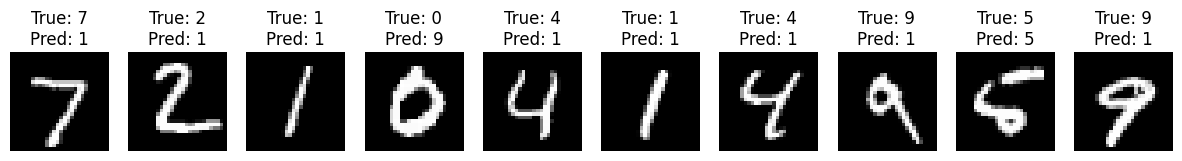

In [19]:
# Plot some test images with predicted labels
def plot_predictions(X, y_true, y_pred, n=10):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = X[i].reshape(28, 28)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {y_true[i]}\nPred: {y_pred[i]}")
        plt.axis('off')
    plt.show()

# Use first 10 examples
plot_predictions(X_batch, true_classes, predicted_classes, n=10)

# Problem 9 (Advanced task) Research into famous image recognition models
Representative CNN structures include AlexNet (2012) and VGG16 (2014). These are often already available in frameworks.

This is a quick search to find out what is available. It's a good idea to at least look at the names.

# 1. VGG16 in Keras
VGG16 is readily available in Keras through the keras.applications module. It comes with pre-trained weights on the ImageNet dataset, making it convenient for tasks like image classification and transfer learning.

In [20]:
# Example
from keras.applications.vgg16 import VGG16

# Load the VGG16 model with pre-trained ImageNet weights
model = VGG16(weights='imagenet')

2025-04-26 10:12:42.757712: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# 2.  AlexNet in Keras
AlexNet is not officially included in Keras' applications module. However, you can find third-party implementations:​

- GitHub Implementation: A Keras implementation of AlexNet is available on GitHub:

- Custom Implementation: You can implement AlexNet manually using Keras layers. Here's a basic outline:

In [21]:
  from keras.models import Sequential
  from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

  model = Sequential()
  model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(227, 227, 3)))
  model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
  model.add(Conv2D(256, (5, 5), activation='relu', padding='same'))
  model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
  model.add(Conv2D(384, (3, 3), activation='relu', padding='same'))
  model.add(Conv2D(384, (3, 3), activation='relu', padding='same'))
  model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
  model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
  model.add(Flatten())
  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(1000, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In summary, VGG16 is officially supported in keras.applications, is available in Keras and has pre-trained weights while AlexNet is a available via third-party implementations with no pre-trained weights.

# Problem 10: Calculating the output size and number of parameters
When building a CNN model, it is necessary to pre-calculate how many features will be input to the fully connected layer.

In addition, when dealing with large models, it becomes necessary to calculate the number of parameters due to memory and calculation speed. Although the framework allows you to display the number of parameters for each layer, you cannot make appropriate adjustments unless you understand their meaning.

Calculate the output size and number of parameters for the following three convolutional layers. Please consider the bias term for the number of parameters.

1.

Input size: 144×144, 3 channels
Filter size: 3×3, 6 channels
Stride: 1
Padding: None
2.

Input size: 60×60, 24 channels
Filter size: 3×3, 48 channels
Stride: 1
Padding: None
3.

Input size: 20×20, 10 channels
Filter size: 3×3, 20 channels
Stride: 2
Padding: None
*The last example is when the convolution cannot be done just right. The framework may ignore the extra pixels, so please take that into account when calculating. This is an example where such a setting is not desirable because the edges will be clipped.

In [22]:
def conv_layer_params(input_size, filter_size, num_input_channels, num_output_channels, stride=1, padding=0):
    # Calculating output size
    output_size = (input_size - filter_size + 2 * padding) // stride + 1
    # Calculating number of parameters (weights + bias)
    params = (filter_size * filter_size * num_input_channels) * num_output_channels + num_output_channels
    return output_size, params

# Example 1
input_size_1 = 144
filter_size_1 = 3
num_input_channels_1 = 3
num_output_channels_1 = 6
stride_1 = 1
output_size_1, params_1 = conv_layer_params(input_size_1, filter_size_1, num_input_channels_1, num_output_channels_1, stride_1)
print(f"Example 1: Output Size: {output_size_1} x {output_size_1} x {num_output_channels_1}, Params: {params_1}")

# Example 2
input_size_2 = 60
filter_size_2 = 3
num_input_channels_2 = 24
num_output_channels_2 = 48
stride_2 = 1
output_size_2, params_2 = conv_layer_params(input_size_2, filter_size_2, num_input_channels_2, num_output_channels_2, stride_2)
print(f"Example 2: Output Size: {output_size_2} x {output_size_2} x {num_output_channels_2}, Params: {params_2}")

# Example 3
input_size_3 = 20
filter_size_3 = 3
num_input_channels_3 = 10
num_output_channels_3 = 20
stride_3 = 2
output_size_3, params_3 = conv_layer_params(input_size_3, filter_size_3, num_input_channels_3, num_output_channels_3, stride_3)
print(f"Example 3: Output Size: {output_size_3} x {output_size_3} x {num_output_channels_3}, Params: {params_3}")

Example 1: Output Size: 142 x 142 x 6, Params: 168
Example 2: Output Size: 58 x 58 x 48, Params: 10416
Example 3: Output Size: 9 x 9 x 20, Params: 1820


# Problem 11: (Advanced) Investigation into filter size
Convolutional layers have a hyperparameter called filter size, and currently, in 2D convolutional layers, 3 × 3 and 1 × 1 are mostly used. We will research each of the following and explain them.

Why are 3x3 filters more commonly used than larger ones like 7x7?
The effect of a 1×1 filter with no height or width

**Why are 3x3 filters more commonly used than larger ones like 7x7?**
1. Smaller Receptive Field with More Layers:

- A 3x3 filter has a small receptive field, but when stacked over several layers, it can achieve the same or even better feature extraction as a large filter (e.g., 7x7).

- For instance, two stacked 3x3 filters can capture a receptive field of 5x5, and three stacked 3x3 filters can capture a 7x7 receptive field. However, this is achieved with more depth in the model, which allows for richer representations and better learning of complex patterns.

2. Fewer Parameters:

- A 3x3 filter has fewer parameters than a larger filter. For example:

A 3x3 filter for each input channel has $3*3=9$ weights per input channel.

A 7x7 filter would have $7×7=49$ weights per input channel.

- Fewer parameters lead to faster computation and less memory usage, making the model easier to train and more efficient.

- Using smaller filters also means fewer chances of overfitting, as the model is simpler and requires fewer parameters.

3. More Flexibility and Control:

- Using multiple small filters (e.g., multiple 3x3) allows the network to learn different kinds of features at different layers. Each 3x3 filter can focus on different local patterns, allowing for more flexibility.

- In comparison, a large filter like 7x7 would capture more global features in one layer, but it's less flexible because it tries to capture too much information at once.

4. Empirical Evidence:

- Research has shown that 3x3 filters perform well across a range of applications, including large-scale models like VGG and ResNet, and are computationally more efficient while achieving excellent results.

- The VGG model (2014) popularized the use of stacked 3x3 filters, and ResNet (2015) showed how smaller filters could work better for learning deeper networks.

**The Effect of a 1×1 Filter with No Height or Width**

A 1×1 filter in a convolutional layer is not used for feature extraction in the traditional sense (i.e., capturing spatial information like edges or textures). Instead, it has the following effects:

1. Channel-wise Operations (Dimensionality Reduction or Expansion):

- A 1x1 filter works by operating on channels rather than spatial features. It effectively acts like a fully connected layer applied to the channels.

- This means that a 1x1 convolution can combine information from different channels at each pixel location, creating new channel representations without affecting spatial dimensions.

- For example, if we have 64 channels and you apply a 1x1 filter with 128 output channels, we are expanding the feature map depth from 64 channels to 128 channels, essentially performing channel-wise mixing.

2. Reducing Computational Load (Dimensionality Reduction):

- A 1x1 filter can be used to reduce the number of channels before passing the data to deeper layers, which can significantly decrease the computation cost.

- For example, if we have 256 channels in one layer and want to reduce it to 64 channels, applying a 1x1 convolution would result in fewer parameters compared to using a larger filter.

3. Used in Bottleneck Layers:

- 1x1 filters are frequently used in bottleneck layers (e.g., in ResNet). A bottleneck layer first reduces the depth (number of channels) using 1x1 convolutions, then applies a larger filter (such as 3x3) to capture spatial features, and finally expands the depth again with another 1x1 convolution. This reduces the computation overhead while preserving expressive power.

4. No Spatial Effect:

- The 1x1 filter does not affect the spatial dimensions of the input (height or width). It only operates on the depth (number of channels), making it useful for transforming the features at each spatial location without altering the spatial structure.

5. Non-Linearity:

- When combined with activation functions like ReLU, 1x1 convolutions can introduce non-linearity between the channels, allowing for better feature learning.